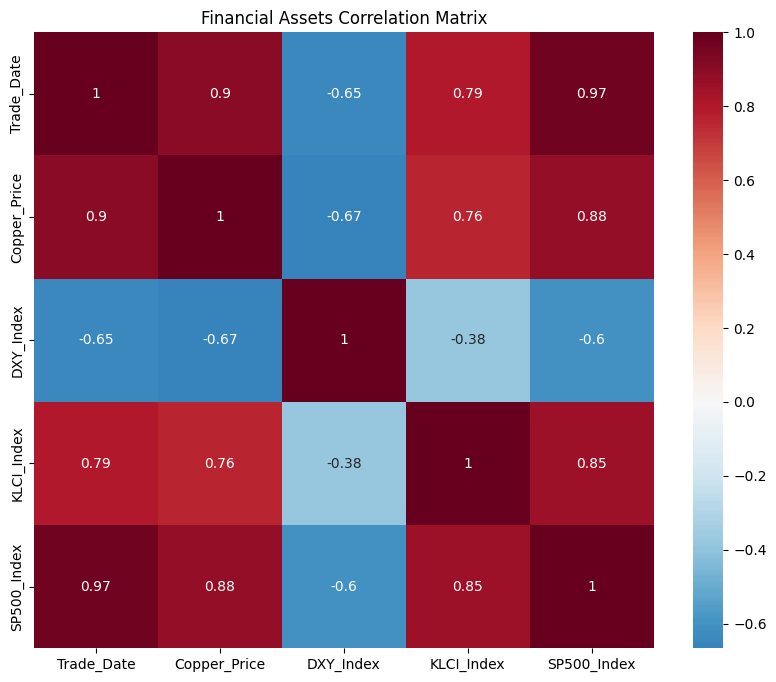

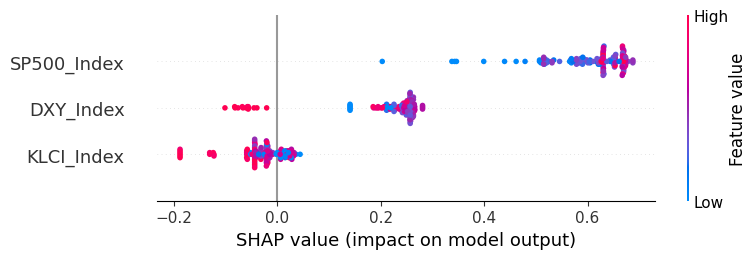

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

# 1. 加载数据
df = pd.read_csv('final_financial_data.csv')
df['Trade_Date'] = pd.to_datetime(df['Trade_Date'])
df = df.sort_values('Trade_Date')

# 2. 相关性分析（宏观因子的关联性）
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Financial Assets Correlation Matrix')
plt.show()

# 3. 准备模型数据
# 我们用 DXY, KLCI, SP500 预测 Copper_Price
X = df[['DXY_Index', 'KLCI_Index', 'SP500_Index']]
y = df['Copper_Price']

# 划分训练集和测试集 (前 80% 训练，后 20% 测试)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 4. 训练 XGBoost 模型
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

# 5. 模型可解释性分析 (SHAP Value)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 绘制 SHAP 摘要图
shap.summary_plot(shap_values, X_test)